# v1 - bottom tracking, shelf release

Particles placed in the **deepest cell of the water column** on the Amazon shelf and tracked for
28 days. Two field sets, identical seeds.

Release depth is the middle of the true bottom cell,
`gdepw_0[mbathy-1] + e3t_ps/2`, so every particle starts inside the deepest existing cell and
above the real seabed `H = gdepw_0[mbathy-1] + e3t_ps`. Nothing is clamped or offset - the
depth follows from the mesh.

In [1]:
n_particles        = 200
run_time_days      = 28
time_step_minutes  = 20
out_put_step_hours = 6

ref_date = "1993-01-01"
offset   = 1                 # release 1993-01-02, ends 1993-01-30
rdm_seed = 110987

Hgr = "Hgr_cmesh.nc"
Zgr = "Zgr_cmesh2.nc"

EXPERIMENTS = {
    "poisson_b": dict(U="U_1993-01b.nc", V="V_1993-01b.nc", W="W_1993-01b.nc"),
    "glorys_Wc": dict(U="U_1993-01.nc",  V="V_1993-01.nc",  W="W_1993-01c.nc"),
}

# shelf, in the Amazon plume box
SHELF_H   = (20.0, 100.0)
BOX       = dict(lon=(-52, -46), lat=(-1.5, 4.5))

out_root    = "bottom_tracks"
FORCE_RERUN = False

In [2]:
import os, sys, shutil, contextlib
import numpy as np
import xarray as xr
from datetime import timedelta
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from parcels import FieldSet, ParticleSet, JITParticle, Variable, AdvectionRK4_3D


@contextlib.contextmanager
def quiet():
    sys.stdout.flush()
    saved, devnull = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 1)
        yield
    finally:
        os.dup2(saved, 1); os.close(devnull); os.close(saved)


start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
print(f"release {start_time} -> {start_time + np.timedelta64(run_time_days,'D')}"
      f"   dt={time_step_minutes} min   output={out_put_step_hours} h")

release 1993-01-02 -> 1993-01-30   dt=20 min   output=6 h


## 1. Where the bottom cell is

In [3]:
zgr = xr.open_dataset(Zgr).squeeze()
mbathy  = zgr.mbathy.values.astype(int)
gdepw_0 = zgr.gdepw_0.squeeze().values.astype("f8")
e3t_0   = zgr.e3t_0.squeeze().values.astype("f8")
e3t_ps  = zgr.e3t_ps.values.astype("f8")
lon2d, lat2d = zgr.nav_lon.values, zgr.nav_lat.values
ny, nx = mbathy.shape

kbot   = np.clip(mbathy - 1, 0, len(gdepw_0) - 2)      # index of the deepest wet T-cell
top    = gdepw_0[kbot]                                  # its upper face
thick  = np.where(mbathy > 0, e3t_ps, 0.0)              # its true thickness (partial cell)
H      = top + thick                                    # true seabed
zbot   = top + 0.5 * thick                              # middle of the bottom cell

wet_j, wet_i = np.where(mbathy > 0)
tree  = cKDTree(np.column_stack([lon2d[wet_j, wet_i], lat2d[wet_j, wet_i]]))
H_wet = H[wet_j, wet_i]
def seabed_at(lo, la):
    f = np.column_stack([np.ravel(lo), np.ravel(la)])
    ok = np.isfinite(f).all(axis=1)
    out = np.full(len(f), np.nan)
    if ok.any(): out[ok] = H_wet[tree.query(f[ok])[1]]
    return out.reshape(np.shape(lo))

shelf = ((mbathy > 0) & (H > SHELF_H[0]) & (H < SHELF_H[1])
         & (lon2d > BOX["lon"][0]) & (lon2d < BOX["lon"][1])
         & (lat2d > BOX["lat"][0]) & (lat2d < BOX["lat"][1]))
print(f"{int(shelf.sum())} shelf columns with {SHELF_H[0]:.0f} < H < {SHELF_H[1]:.0f} m in the box")

1104 shelf columns with 20 < H < 100 m in the box


In [4]:
rng = np.random.default_rng(rdm_seed)
jj, ii = np.where(shelf)
pick = rng.choice(len(jj), size=n_particles, replace=len(jj) < n_particles)
pj, pi = jj[pick], ii[pick]

start_lon   = lon2d[pj, pi]
start_lat   = lat2d[pj, pi]
start_depth = zbot[pj, pi]

assert np.all(start_depth < H[pj, pi]), "a seed landed on or below the seabed"
print(f"{n_particles} particles")
print(f"  release depth   {start_depth.min():7.2f} - {start_depth.max():7.2f} m")
print(f"  local seabed    {H[pj,pi].min():7.2f} - {H[pj,pi].max():7.2f} m")
print(f"  height above bed {(H[pj,pi]-start_depth).min():6.2f} - {(H[pj,pi]-start_depth).max():6.2f} m")
print(f"  bottom cell is {np.median(thick[pj,pi]/e3t_0[kbot[pj,pi]]):.0%} of a full cell (median)")

200 particles
  release depth     20.49 -   91.87 m
  local seabed      21.00 -   98.98 m
  height above bed   0.50 -   7.11 m
  bottom cell is 72% of a full cell (median)


## 2. Track

In [5]:
def make_fieldset(f):
    filenames = {v: {"data": f[v], "lon": Hgr, "lat": Hgr, "depth": f["W"]}
                 for v in ("U", "V", "W")}
    variables = {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"}
    dimensions = {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw",
                      "time": "time_counter"} for v in variables}
    return FieldSet.from_netcdf(
        filenames, variables, dimensions,
        interp_method={v: "cgrid_velocity" for v in variables},
        deferred_load=True, allow_time_extrapolation=False, gridindexingtype="nemo")


def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()


def run(tag, f):
    out = os.path.join(out_root, f"{tag}.zarr")
    if os.path.exists(out) and not FORCE_RERUN:
        print(f"  reusing {out}")
        return out
    if os.path.exists(out):
        shutil.rmtree(out)
    os.makedirs(out_root, exist_ok=True)
    pset = ParticleSet(fieldset=make_fieldset(f), pclass=JITParticle,
                       lon=start_lon, lat=start_lat, depth=start_depth,
                       time=np.datetime64(start_time))
    pfile = pset.ParticleFile(
        name=out, outputdt=timedelta(hours=out_put_step_hours),
        # whole obs axis up front - Parcels' zarr writer breaks if it has to extend it
        chunks=(n_particles, int(run_time_days * 24 / out_put_step_hours) + 2))
    with quiet():
        pset.execute([AdvectionRK4_3D, CheckError],
                     runtime=timedelta(days=run_time_days),
                     dt=timedelta(minutes=time_step_minutes),
                     output_file=pfile)
    return out

paths = {}
for tag, f in EXPERIMENTS.items():
    print(f"===== {tag} =====")
    paths[tag] = run(tag, f)
print("done")

===== poisson_b =====
  reusing bottom_tracks/poisson_b.zarr
===== glorys_Wc =====
  reusing bottom_tracks/glorys_Wc.zarr
done


In [6]:
TRK = {}
for tag, pth in paths.items():
    d = xr.open_zarr(pth).compute()
    lat = d.lat.values
    keep = np.isfinite(lat).any(axis=0)          # drop the unwritten tail of the obs axis
    lon_, lat_ = d.lon.values[:, keep], lat[:, keep]
    z_ = np.where(np.isfinite(lat_), d.z.values[:, keep], np.nan)
    TRK[tag] = dict(lon=lon_, lat=lat_, z=z_, bed=seabed_at(lon_, lat_),
                    t=np.arange(keep.sum()) * out_put_step_hours / 24.0)
    print(f"{tag:<10} {lon_.shape[0]} trajectories, {lon_.shape[1]} outputs, "
          f"to day {TRK[tag]['t'][-1]:.2f}")

poisson_b  200 trajectories, 112 outputs, to day 27.75
glorys_Wc  200 trajectories, 112 outputs, to day 27.75


## 3. Tracks

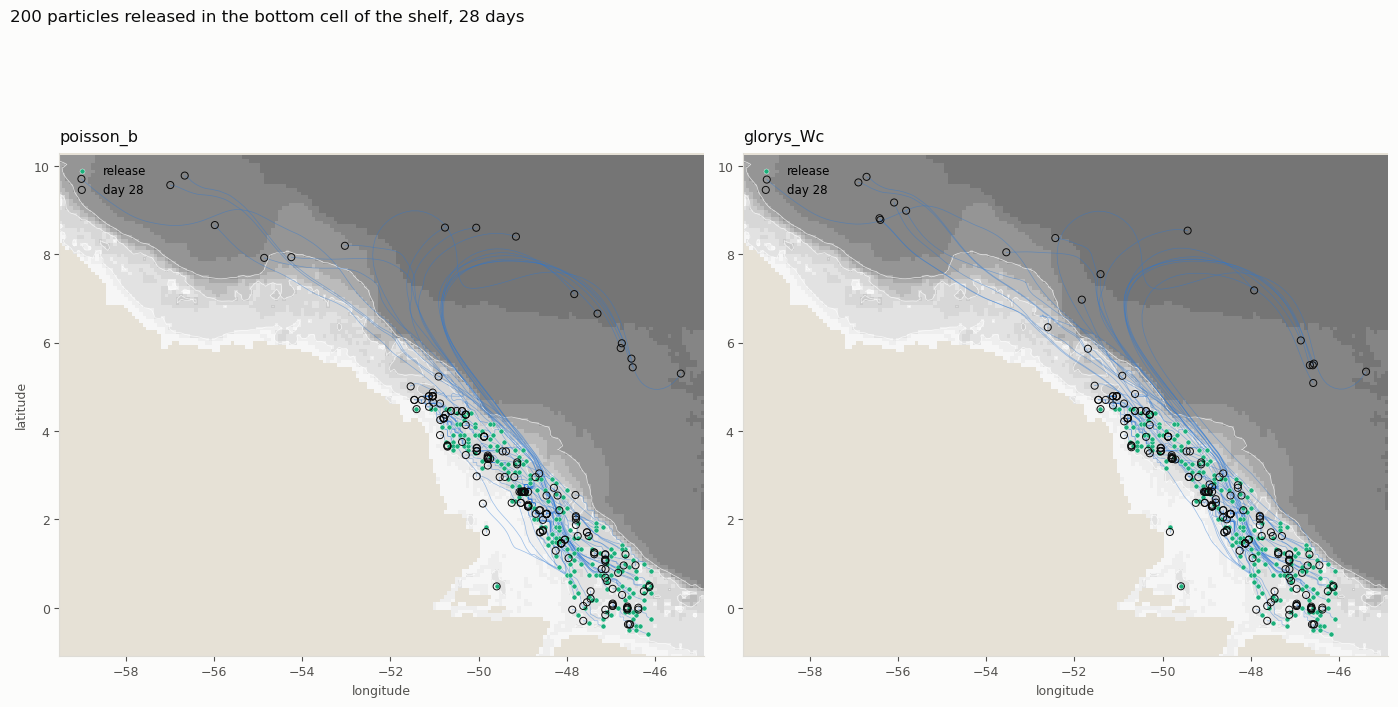

In [7]:
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

allon = np.concatenate([v["lon"].ravel() for v in TRK.values()])
allat = np.concatenate([v["lat"].ravel() for v in TRK.values()])
pad = 0.5
x0, x1 = np.nanmin(allon) - pad, np.nanmax(allon) + pad
y0, y1 = np.nanmin(allat) - pad, np.nanmax(allat) + pad
sub = (lon2d >= x0) & (lon2d <= x1) & (lat2d >= y0) & (lat2d <= y1)
sj, si = np.where(sub)
J, I = slice(sj.min(), sj.max() + 1), slice(si.min(), si.max() + 1)
BLON, BLAT = lon2d[J, I], lat2d[J, I]
BATH = np.where(mbathy[J, I] > 0, H[J, I], np.nan)

LEV = [0, 10, 20, 50, 100, 200, 500, 1000, 2000, 4000, 6000]
import matplotlib as mpl
bcmap = ListedColormap(mpl.colormaps["Greys"](np.linspace(0.08, 0.62, len(LEV) - 1)))
bcmap.set_bad("#e6e1d6")
bnorm = BoundaryNorm(LEV, bcmap.N)

fig, axs = plt.subplots(1, len(TRK), figsize=(7.0 * len(TRK), 7.4), squeeze=False)
for ax, (tag, v) in zip(axs[0], TRK.items()):
    ax.set_facecolor("#e6e1d6")
    ax.pcolormesh(BLON, BLAT, BATH, cmap=bcmap, norm=bnorm, shading="auto", zorder=0)
    ax.contour(BLON, BLAT, np.nan_to_num(BATH), levels=[20, 100, 1000],
               colors="#ffffff", linewidths=0.5, alpha=0.75, zorder=1)
    ax.plot(v["lon"].T, v["lat"].T, lw=0.5, color="#2a78d6", alpha=0.45, zorder=2)
    ax.scatter(v["lon"][:, 0], v["lat"][:, 0], s=13, color="#1baf7a",
               edgecolor="white", linewidth=0.3, zorder=4, label="release")
    nob = np.isfinite(v["lat"]).sum(axis=1)
    last = np.where(nob > 0, nob - 1, 0); r = np.arange(len(last))
    ax.scatter(v["lon"][r, last], v["lat"][r, last], s=26, facecolor="none",
               edgecolor="#0b0b0b", linewidth=0.7, zorder=5, label=f"day {run_time_days}")
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_aspect(1 / np.cos(np.deg2rad(np.mean([y0, y1]))))
    ax.set_title(tag, loc="left", fontsize=11.5, pad=9)
    ax.set_xlabel("longitude")
    ax.legend(frameon=False, fontsize=8.5, loc="upper left")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
axs[0, 0].set_ylabel("latitude")
fig.suptitle(f"{n_particles} particles released in the bottom cell of the shelf, "
             f"{run_time_days} days", x=0.006, ha="left", fontsize=12, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("v1_bottom_tracks_map.png", dpi=170, facecolor=SURF)
plt.show()

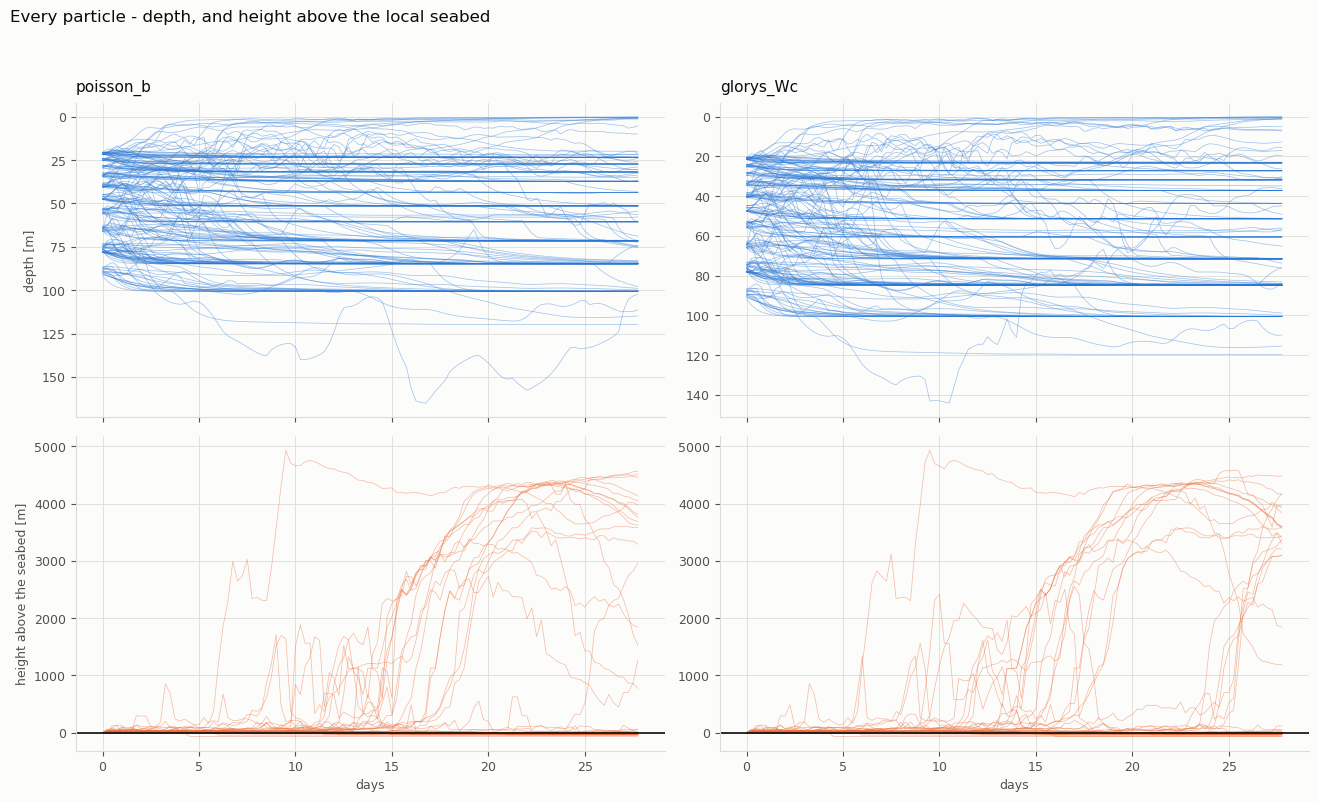

In [8]:
fig, axs = plt.subplots(2, len(TRK), figsize=(6.6 * len(TRK), 8.0), squeeze=False, sharex=True)
for c, (tag, v) in enumerate(TRK.items()):
    ax = axs[0, c]
    ax.plot(v["t"], v["z"].T, lw=0.5, color="#2a78d6", alpha=0.45)
    ax.invert_yaxis()
    ax.set_title(tag, loc="left", fontsize=11, pad=8)
    if c == 0: ax.set_ylabel("depth [m]")
    ax = axs[1, c]
    ax.plot(v["t"], (v["bed"] - v["z"]).T, lw=0.5, color="#eb6834", alpha=0.45)
    ax.axhline(0, lw=1.2, color="#0b0b0b")
    ax.set_xlabel("days")
    if c == 0: ax.set_ylabel("height above the seabed [m]")
for ax in axs.ravel():
    ax.grid(True, lw=0.6, color=GRID); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.suptitle("Every particle - depth, and height above the local seabed",
             x=0.006, ha="left", fontsize=12, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("v1_bottom_tracks_depth.png", dpi=170, facecolor=SURF)
plt.show()

## 4. Any particle that did not move?


In [9]:
R = 6371.0
def gc_km(lo1, la1, lo2, la2):
    """Haversine in float64. The arccos form loses all precision at short range and,
    on the float32 positions zarr stores, reports kilometres for a particle that never
    moved - which is how a static particle can hide behind a 4.6 km 'path'."""
    q = np.pi / 180
    la1, la2 = np.asarray(la1, "f8") * q, np.asarray(la2, "f8") * q
    dlo = (np.asarray(lo2, "f8") - np.asarray(lo1, "f8")) * q
    h = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin(dlo / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(h, 0, 1)))

STUCK = {}
for tag, v in TRK.items():
    path = np.nansum(gc_km(v["lon"][:, :-1], v["lat"][:, :-1],
                           v["lon"][:, 1:],  v["lat"][:, 1:]), axis=1)
    dz   = np.nanmax(v["z"], axis=1) - np.nanmin(v["z"], axis=1)
    STUCK[tag] = (path, dz)
    q = np.argsort(path)[:6]
    print(f"=== {tag} ===  path over {run_time_days} d [km], and vertical range [m]")
    for a in q:
        print(f"   #{a:>4}  path {path[a]:9.3f} km   dz {dz[a]:7.3f} m   "
              f"start ({v['lon'][a,0]:8.3f},{v['lat'][a,0]:7.3f}) z0={v['z'][a,0]:6.2f} "
              f"bed={v['bed'][a,0]:6.2f}")
    print(f"   particles with path < 1 km: {int((path < 1).sum())}\n")

=== poisson_b ===  path over 28 d [km], and vertical range [m]
   # 131  path     4.619 km   dz   8.758 m   start ( -50.500,  4.412) z0= 91.87 bed= 98.98
   # 111  path     4.623 km   dz   3.714 m   start ( -50.667,  3.664) z0= 28.12 bed= 29.00
   #  55  path     4.629 km   dz   4.837 m   start ( -48.833,  2.333) z0= 32.42 bed= 33.00
   # 161  path     4.630 km   dz  10.006 m   start ( -48.167,  2.249) z0= 90.62 bed= 96.48
   #  59  path     4.631 km   dz   7.282 m   start ( -47.500,  1.583) z0= 64.27 bed= 67.99
   #  76  path     4.631 km   dz   7.869 m   start ( -47.750,  1.583) z0= 52.69 bed= 54.00
   particles with path < 1 km: 0

=== glorys_Wc ===  path over 28 d [km], and vertical range [m]
   # 131  path     4.619 km   dz   8.758 m   start ( -50.500,  4.412) z0= 91.87 bed= 98.98
   # 111  path     4.623 km   dz   3.714 m   start ( -50.667,  3.664) z0= 28.12 bed= 29.00
   #  55  path     4.629 km   dz   4.839 m   start ( -48.833,  2.333) z0= 32.42 bed= 33.00
   # 161  path     4.

In [10]:
# for the least mobile ones: is the cell wet, and what velocity does the file actually hold?
tag0 = list(TRK)[0]
f0   = EXPERIMENTS[tag0]
dU = xr.open_dataset(f0["U"]); dV = xr.open_dataset(f0["V"]); dW = xr.open_dataset(f0["W"])
v   = TRK[tag0]
path = STUCK[tag0][0]

for a in np.argsort(path)[:4]:
    lo, la, z0 = v["lon"][a, 0], v["lat"][a, 0], v["z"][a, 0]
    w_ = tree.query([[lo, la]])[1][0]
    j, i = wet_j[w_], wet_i[w_]
    mb = int(mbathy[j, i])
    kc = int(np.clip(np.searchsorted(gdepw_0, z0) - 1, 0, len(gdepw_0) - 2))
    print(f"#{a}  ({lo:.3f},{la:.3f})  z0={z0:.2f}  bed={H[j,i]:.2f}  mbathy={mb}  "
          f"cell k={kc}  {'WET' if kc + 1 <= mb else 'DRY'}")
    print(f"     path {path[a]:.3f} km over {run_time_days} days"
          f"  = {path[a]*1000/(run_time_days*86400):.5f} m/s mean")
    uu = dU.vozocrtx.isel(y=j, x=i, deptht=kc).values
    vv = dV.vomecrty.isel(y=j, x=i, deptht=kc).values
    ww = dW.vovecrtz.isel(y=j, x=i, depthw=kc).values
    # the four faces bounding this T-cell
    uw = dU.vozocrtx.isel(y=j, x=max(i-1, 0), deptht=kc).values
    vs = dV.vomecrty.isel(y=max(j-1, 0), x=i, deptht=kc).values
    print(f"     U east {np.nanmean(np.abs(uu)):.3e}  U west {np.nanmean(np.abs(uw)):.3e}  "
          f"V north {np.nanmean(np.abs(vv)):.3e}  V south {np.nanmean(np.abs(vs)):.3e}  "
          f"|W| {np.nanmean(np.abs(ww)):.3e}   (month means, m/s)")
    nb_ = mbathy[max(j-1,0):j+2, max(i-1,0):i+2]
    print(f"     mbathy of the 3x3 neighbourhood:\n{nb_}\n")

#131  (-50.500,4.412)  z0=91.87  bed=98.98  mbathy=22  cell k=21  WET
     path 4.619 km over 28 days  = 0.00191 m/s mean
     U east 0.000e+00  U west 0.000e+00  V north 0.000e+00  V south 1.624e-01  |W| 2.325e-04   (month means, m/s)
     mbathy of the 3x3 neighbourhood:
[[21 22 20]
 [21 22 17]
 [20 19 20]]

#111  (-50.667,3.664)  z0=28.12  bed=29.00  mbathy=15  cell k=14  WET
     path 4.623 km over 28 days  = 0.00191 m/s mean
     U east 8.253e-02  U west 0.000e+00  V north 0.000e+00  V south 0.000e+00  |W| 1.566e-05   (month means, m/s)
     mbathy of the 3x3 neighbourhood:
[[12 14 15]
 [13 15 16]
 [13 14 16]]

#55  (-48.833,2.333)  z0=32.42  bed=33.00  mbathy=16  cell k=15  WET
     path 4.629 km over 28 days  = 0.00191 m/s mean
     U east 1.145e-01  U west 0.000e+00  V north 0.000e+00  V south 0.000e+00  |W| 1.439e-05   (month means, m/s)
     mbathy of the 3x3 neighbourhood:
[[12 14 16]
 [13 16 16]
 [14 12 18]]

#161  (-48.167,2.249)  z0=90.62  bed=96.48  mbathy=22  cell k=21 

## 5. Are the bottom cells really walled in?

Checked from the mask, not from sampled velocities. In NEMO a face velocity carries `umask` /
`vmask`: `U` at the face between `T(j,i)` and `T(j,i+1)` exists only if **both** cells are wet
at that level. A closed face is a solid wall, and zero there is the correct value, not missing
data. The question is how many of the four faces of a *bottom* cell are open.

In [11]:
k3 = np.arange(len(gdepw_0) - 1)[:, None, None]
wet3 = (k3 + 1) <= mbathy                       # tmask

# a face is open only if the two T-cells it separates are both wet at that level
ue = np.zeros_like(wet3); ue[:, :, :-1] = wet3[:, :, :-1] & wet3[:, :, 1:]   # east face of T(i)
uw = np.zeros_like(wet3); uw[:, :,  1:] = wet3[:, :, :-1] & wet3[:, :, 1:]   # west face of T(i)
vn = np.zeros_like(wet3); vn[:, :-1, :] = wet3[:, :-1, :] & wet3[:, 1:, :]   # north face
vs = np.zeros_like(wet3); vs[:,  1:, :] = wet3[:, :-1, :] & wet3[:, 1:, :]   # south face
nopen = (ue.astype(int) + uw.astype(int) + vn.astype(int) + vs.astype(int))

kb = np.clip(mbathy - 1, 0, len(gdepw_0) - 2)
JJ, II = np.indices(mbathy.shape)
nopen_bot = nopen[kb, JJ, II]                   # open faces of the DEEPEST wet cell

print("open horizontal faces of the bottom cell, shelf columns in the box:")
tot = int(shelf.sum())
for n in range(5):
    c = int((shelf & (nopen_bot == n)).sum())
    print(f"   {n} open face(s): {c:>6}  ({100*c/tot:5.1f}%)")
print(f"\nfor comparison, the cell ONE level above the bottom:")
ka = np.clip(mbathy - 2, 0, len(gdepw_0) - 2)
nopen_ab = nopen[ka, JJ, II]
for n in range(5):
    c = int((shelf & (mbathy > 1) & (nopen_ab == n)).sum())
    print(f"   {n} open face(s): {c:>6}  ({100*c/max(tot,1):5.1f}%)")

open horizontal faces of the bottom cell, shelf columns in the box:
   0 open face(s):      0  (  0.0%)
   1 open face(s):    157  ( 14.2%)
   2 open face(s):    348  ( 31.5%)
   3 open face(s):    326  ( 29.5%)
   4 open face(s):    273  ( 24.7%)

for comparison, the cell ONE level above the bottom:
   0 open face(s):      0  (  0.0%)
   1 open face(s):     28  (  2.5%)
   2 open face(s):    149  ( 13.5%)
   3 open face(s):    300  ( 27.2%)
   4 open face(s):    627  ( 56.8%)


In [12]:
# does the mask agree with what the FILES contain, for both field sets?
print("mask vs file, at the release cell of the six least mobile particles\n")
v = TRK[list(TRK)[0]]
path = STUCK[list(TRK)[0]][0]
gl_U = xr.open_dataset("U_1993-01.nc").vozocrtx
gl_V = xr.open_dataset("V_1993-01.nc").vomecrty

for a in np.argsort(path)[:6]:
    lo, la, z0 = v["lon"][a, 0], v["lat"][a, 0], v["z"][a, 0]
    w_ = tree.query([[lo, la]])[1][0]
    j, i = wet_j[w_], wet_i[w_]
    k = int(mbathy[j, i]) - 1
    faces = dict(east=bool(ue[k, j, i]), west=bool(uw[k, j, i]),
                 north=bool(vn[k, j, i]), south=bool(vs[k, j, i]))
    # what GLORYS itself holds there (NaN = masked by the model)
    gu_e = float(gl_U.isel(time_counter=1, deptht=k, y=j, x=i).values)
    gu_w = float(gl_U.isel(time_counter=1, deptht=k, y=j, x=max(i-1, 0)).values)
    gv_n = float(gl_V.isel(time_counter=1, deptht=k, y=j, x=i).values)
    gv_s = float(gl_V.isel(time_counter=1, deptht=k, y=max(j-1, 0), x=i).values)
    print(f"#{a:>4} (j={j}, i={i}) k={k}  mask open: "
          f"{', '.join(n for n, o in faces.items() if o) or 'NONE'}   "
          f"({sum(faces.values())} of 4)")
    print(f"      GLORYS raw:  U_e {gu_e:>10.3e}  U_w {gu_w:>10.3e}  "
          f"V_n {gv_n:>10.3e}  V_s {gv_s:>10.3e}   (nan = model land mask)")

mask vs file, at the release cell of the six least mobile particles

# 131 (j=173, i=534) k=21  mask open: south   (1 of 4)
      GLORYS raw:  U_e        nan  U_w        nan  V_n        nan  V_s  2.253e-01   (nan = model land mask)
# 111 (j=164, i=532) k=14  mask open: east   (1 of 4)
      GLORYS raw:  U_e -8.935e-02  U_w        nan  V_n        nan  V_s        nan   (nan = model land mask)
#  55 (j=148, i=554) k=15  mask open: east   (1 of 4)
      GLORYS raw:  U_e -1.336e-01  U_w        nan  V_n        nan  V_s        nan   (nan = model land mask)
# 161 (j=147, i=562) k=21  mask open: north   (1 of 4)
      GLORYS raw:  U_e        nan  U_w        nan  V_n -6.313e-02  V_s        nan   (nan = model land mask)
#  59 (j=139, i=570) k=19  mask open: south   (1 of 4)
      GLORYS raw:  U_e        nan  U_w        nan  V_n        nan  V_s  1.125e-01   (nan = model land mask)
#  76 (j=139, i=567) k=18  mask open: south   (1 of 4)
      GLORYS raw:  U_e        nan  U_w        nan  V_n        n

/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


## 6. Does continuity hold in a one-face bottom cell?

It must, and it does - the closed horizontal faces are not a leak because the **top** face
carries the balance. For the deepest wet cell, $k = $ `mbathy-1`, the seabed below it is solid
so $w_{k+1} = 0$, and the budget reduces to

$$w_k A \;=\; -\big(F^u_i - F^u_{i-1} + F^v_j - F^v_{j-1}\big)_k$$

i.e. **whatever comes in horizontally leaves vertically.** A one-face bottom cell is a cul-de-sac
that converts horizontal inflow entirely into vertical flow. Checked below: the residual should
be zero.

In [13]:
hgr = xr.open_dataset(Hgr).squeeze()
e1t, e2t = hgr.e1t.values.astype("f8"), hgr.e2t.values.astype("f8")
e2u, e1v = e2t, e1t                     # u-face spans e2t, v-face spans e1t
area = e1t * e2t

kk = np.arange(len(e3t_0))[:, None, None]          # full 50 T-levels
wetf = (kk + 1) <= mbathy
e3t = np.where(kk + 1 <= mbathy - 1, e3t_0[:, None, None], e3t_ps)
e3t = np.where(wetf, e3t, 0.0)
def fmin(a, ax):
    b = np.minimum(a, np.roll(a, -1, axis=ax))
    if ax == 2: b[:, :, -1] = a[:, :, -1]
    else:       b[:, -1, :] = a[:, -1, :]
    return b
e3u, e3v = fmin(e3t, 2), fmin(e3t, 1)

TDAY = 1
for tag in TRK:
    f = EXPERIMENTS[tag]
    u = np.nan_to_num(xr.open_dataset(f["U"]).vozocrtx.isel(time_counter=TDAY).values).astype("f8")
    vv= np.nan_to_num(xr.open_dataset(f["V"]).vomecrty.isel(time_counter=TDAY).values).astype("f8")
    w = np.nan_to_num(xr.open_dataset(f["W"]).vovecrtz.isel(time_counter=TDAY).values).astype("f8")
    Fu, Fv = u * e2u * e3u, vv * e1v * e3v

    print(f"=== {tag} ===   bottom-cell budget:  w_k  vs  -(net horizontal outflow)/A")
    vt = TRK[tag]; pth = STUCK[tag][0]
    for a in np.argsort(pth)[:4]:
        w_ = tree.query([[vt['lon'][a,0], vt['lat'][a,0]]])[1][0]
        j, i = wet_j[w_], wet_i[w_]
        k = int(mbathy[j, i]) - 1
        out = (Fu[k,j,i] - Fu[k,j,i-1]) + (Fv[k,j,i] - Fv[k,j-1,i])
        wk, wk1 = w[k,j,i], (w[k+1,j,i] if k+1 < w.shape[0] else 0.0)
        pred = -out / area[j,i] + wk1
        print(f"  #{a:>4} (j={j},i={i},k={k})  w_k(file) {wk:+.4e}   "
              f"-div/A + w_(k+1) {pred:+.4e}   residual {wk-pred:+.2e}   "
              f"w_(k+1) {wk1:+.1e}")
    print()

=== poisson_b ===   bottom-cell budget:  w_k  vs  -(net horizontal outflow)/A
  # 131 (j=173,i=534,k=21)  w_k(file) +3.2228e-04   -div/A + w_(k+1) +3.2230e-04   residual -1.78e-08   w_(k+1) -0.0e+00
  # 111 (j=164,i=532,k=14)  w_k(file) +1.6968e-05   -div/A + w_(k+1) +1.6968e-05   residual -1.02e-13   w_(k+1) -0.0e+00
  #  55 (j=148,i=554,k=15)  w_k(file) +1.6797e-05   -div/A + w_(k+1) +1.6797e-05   residual -9.01e-13   w_(k+1) -0.0e+00
  # 161 (j=147,i=562,k=21)  w_k(file) +8.0722e-05   -div/A + w_(k+1) +8.0724e-05   residual -2.33e-09   w_(k+1) -0.0e+00



/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


=== glorys_Wc ===   bottom-cell budget:  w_k  vs  -(net horizontal outflow)/A
  # 131 (j=173,i=534,k=21)  w_k(file) +3.2138e-04   -div/A + w_(k+1) +3.2244e-04   residual -1.06e-06   w_(k+1) -0.0e+00
  # 111 (j=164,i=532,k=14)  w_k(file) +1.7150e-05   -div/A + w_(k+1) +1.6956e-05   residual +1.94e-07   w_(k+1) -0.0e+00
  #  55 (j=148,i=554,k=15)  w_k(file) +1.7235e-05   -div/A + w_(k+1) +1.6781e-05   residual +4.53e-07   w_(k+1) -0.0e+00
  # 161 (j=147,i=562,k=21)  w_k(file) +8.6335e-05   -div/A + w_(k+1) +7.9947e-05   residual +6.39e-06   w_(k+1) -0.0e+00



In [14]:
# and what does the particle actually feel? W is interpolated between w_k at the cell top
# and w_(k+1) = 0 at the seabed, so its sign decides whether the particle rises or sinks.
tag = list(TRK)[0]
f = EXPERIMENTS[tag]
w = np.nan_to_num(xr.open_dataset(f["W"]).vovecrtz.isel(time_counter=TDAY).values).astype("f8")
vt, pth = TRK[tag], STUCK[tag][0]
print(f"{'id':>5}{'w at cell top':>16}{'w at seabed':>13}   vertical fate over 28 d")
for a in np.argsort(pth)[:6]:
    w_ = tree.query([[vt['lon'][a,0], vt['lat'][a,0]]])[1][0]
    j, i = wet_j[w_], wet_i[w_]
    k = int(mbathy[j, i]) - 1
    z0, zend = vt["z"][a, 0], vt["z"][a][np.isfinite(vt["lat"][a])][-1]
    print(f"{a:>5}{w[k,j,i]:>16.3e}{(w[k+1,j,i] if k+1<w.shape[0] else 0.0):>13.1e}   "
          f"z {z0:6.2f} -> {zend:6.2f} m  (bed {H[j,i]:.2f})  "
          f"{'sank' if zend > z0 else 'rose'}")

   id   w at cell top  w at seabed   vertical fate over 28 d
  131       3.223e-04     -0.0e+00   z  91.87 -> 100.63 m  (bed 98.98)  sank
  111       1.697e-05     -0.0e+00   z  28.12 ->  31.83 m  (bed 29.00)  sank
   55       1.680e-05     -0.0e+00   z  32.42 ->  37.25 m  (bed 33.00)  sank
  161       8.072e-05     -0.0e+00   z  90.62 -> 100.63 m  (bed 96.48)  sank
   59       8.969e-05     -0.0e+00   z  64.27 ->  71.56 m  (bed 67.99)  sank
   76       3.894e-05     -0.0e+00   z  52.69 ->  60.56 m  (bed 54.00)  sank


## 7. Which sign of W did Parcels apply?

Measured directly: compare each particle's observed $dz/dt$ between two outputs against the
field's own W interpolated at its position. If $dz/dt = +W$ then Parcels added W to `depth`,
and since `depth` increases **downward** on this grid (`gdepw_0`: 0 at the surface, 5500 m at
the bottom) that means a positive - i.e. upward, in NEMO's convention - W drives the particle
*deeper*.

In [15]:
tag = "poisson_b"
w3 = np.nan_to_num(xr.open_dataset(EXPERIMENTS[tag]["W"]).vovecrtz.isel(time_counter=TDAY).values).astype("f8")
v  = TRK[tag]
dt_s = out_put_step_hours * 3600.0

# use the first output interval, where the particle is still at its release cell/day
obs = 1
dzdt, wsamp = [], []
for a in range(v["lon"].shape[0]):
    lo, la, z0 = v["lon"][a, 0], v["lat"][a, 0], v["z"][a, 0]
    z1 = v["z"][a, obs]
    if not np.isfinite(z1): continue
    q = tree.query([[lo, la]])[1][0]
    j, i = wet_j[q], wet_i[q]
    zi = int(np.clip(np.searchsorted(gdepw_0, z0) - 1, 0, len(gdepw_0) - 2))
    zeta = (z0 - gdepw_0[zi]) / (gdepw_0[zi + 1] - gdepw_0[zi])
    wint = (1 - zeta) * w3[zi, j, i] + zeta * (w3[zi + 1, j, i] if zi + 1 < w3.shape[0] else 0.0)
    dzdt.append((z1 - z0) / dt_s); wsamp.append(wint)

dzdt, wsamp = np.array(dzdt), np.array(wsamp)
ok = np.abs(wsamp) > 1e-7
print(f"{ok.sum()} particles with |W| > 1e-7 m/s at release\n")
print(f"  correlation( dz/dt , +W )  = {np.corrcoef(dzdt[ok], wsamp[ok])[0,1]:+.4f}")
print(f"  correlation( dz/dt , -W )  = {np.corrcoef(dzdt[ok], -wsamp[ok])[0,1]:+.4f}")
print(f"  best-fit slope dz/dt = a*W :  a = {np.polyfit(wsamp[ok], dzdt[ok], 1)[0]:+.3f}")
print(f"\n  fraction where sign(dz/dt) == sign(W): {np.mean(np.sign(dzdt[ok])==np.sign(wsamp[ok])):.3f}")
print("\n  => a = +1 means Parcels used  depth += W*dt  (deeper for NEMO-upward W)")

197 particles with |W| > 1e-7 m/s at release

  correlation( dz/dt , +W )  = +0.8876
  correlation( dz/dt , -W )  = -0.8876
  best-fit slope dz/dt = a*W :  a = +1.078

  fraction where sign(dz/dt) == sign(W): 0.975

  => a = +1 means Parcels used  depth += W*dt  (deeper for NEMO-upward W)


In [16]:
# What SHOULD happen in a cul-de-sac bottom cell, from geometry alone:
# the seabed is solid, so w_(k+1) = 0; net horizontal INflow can only leave upward.
tag = "poisson_b"
f = EXPERIMENTS[tag]
u = np.nan_to_num(xr.open_dataset(f["U"]).vozocrtx.isel(time_counter=TDAY).values).astype("f8")
vv= np.nan_to_num(xr.open_dataset(f["V"]).vomecrty.isel(time_counter=TDAY).values).astype("f8")
Fu, Fv = u * e2u * e3u, vv * e1v * e3v
vt, pth = TRK[tag], STUCK[tag][0]

print(f"{'id':>5}{'net horiz.':>13}{'w_k':>12}   physics says      Parcels did")
for a in np.argsort(pth)[:6]:
    q = tree.query([[vt['lon'][a,0], vt['lat'][a,0]]])[1][0]
    j, i = wet_j[q], wet_i[q]
    k = int(mbathy[j, i]) - 1
    out = (Fu[k,j,i] - Fu[k,j,i-1]) + (Fv[k,j,i] - Fv[k,j-1,i])
    z0 = vt["z"][a, 0]; zend = vt["z"][a][np.isfinite(vt["lat"][a])][-1]
    print(f"{a:>5}{out:>13.2e}{w3[k,j,i]:>12.2e}   "
          f"{'inflow -> must rise':<18}{'sank %.1f -> %.1f m (bed %.1f)' % (z0, zend, H[j,i])}")

   id   net horiz.         w_k   physics says      Parcels did
  131    -2.75e+04    3.22e-04   inflow -> must risesank 91.9 -> 100.6 m (bed 99.0)
  111    -1.45e+03    1.70e-05   inflow -> must risesank 28.1 -> 31.8 m (bed 29.0)
   55    -1.44e+03    1.68e-05   inflow -> must risesank 32.4 -> 37.3 m (bed 33.0)
  161    -6.92e+03    8.07e-05   inflow -> must risesank 90.6 -> 100.6 m (bed 96.5)
   59    -7.70e+03    8.97e-05   inflow -> must risesank 64.3 -> 71.6 m (bed 68.0)
   76    -3.34e+03    3.89e-05   inflow -> must risesank 52.7 -> 60.6 m (bed 54.0)
